<a href="https://colab.research.google.com/github/thanikshamary-123/Data-analytics-python-project/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Step 1: Loading Dataset ---
Initial Dataset Shape: (16, 5)
   Employee_ID   Department Salary_Level  Experience_Years  Left
0          101        Sales          Low                 1     1
1          102           HR         High                 7     0
2          103  Engineering       Medium                 5     0
3          104        Sales       Medium                 2     1
4          105  Engineering          Low                 3     1 

--- Step 2: Data Cleaning ---
Missing Values per Column:
Employee_ID         0
Department          0
Salary_Level        0
Experience_Years    0
Left                0
dtype: int64
Duplicate rows found: 1
Duplicates removed successfully.
Cleaned Dataset Shape: (15, 5)

--- Step 3: Analyzing Attrition Trends ---

[Insights] Attrition Rate by Department (%):
Department
Engineering    16.67
HR             33.33
Sales          66.67
Name: Left, dtype: float64

[Insights] Attrition Rate by Salary Level (%):
Salary_Level
High        0.00
Low     

/tmp/ipykernel_2337/3105147223.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exp_analysis = df.groupby('Experience_Group')['Left'].mean() * 100
/tmp/ipykernel_2337/3105147223.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=dept_analysis.index, y=dept_analysis.values, palette='Oranges_r')


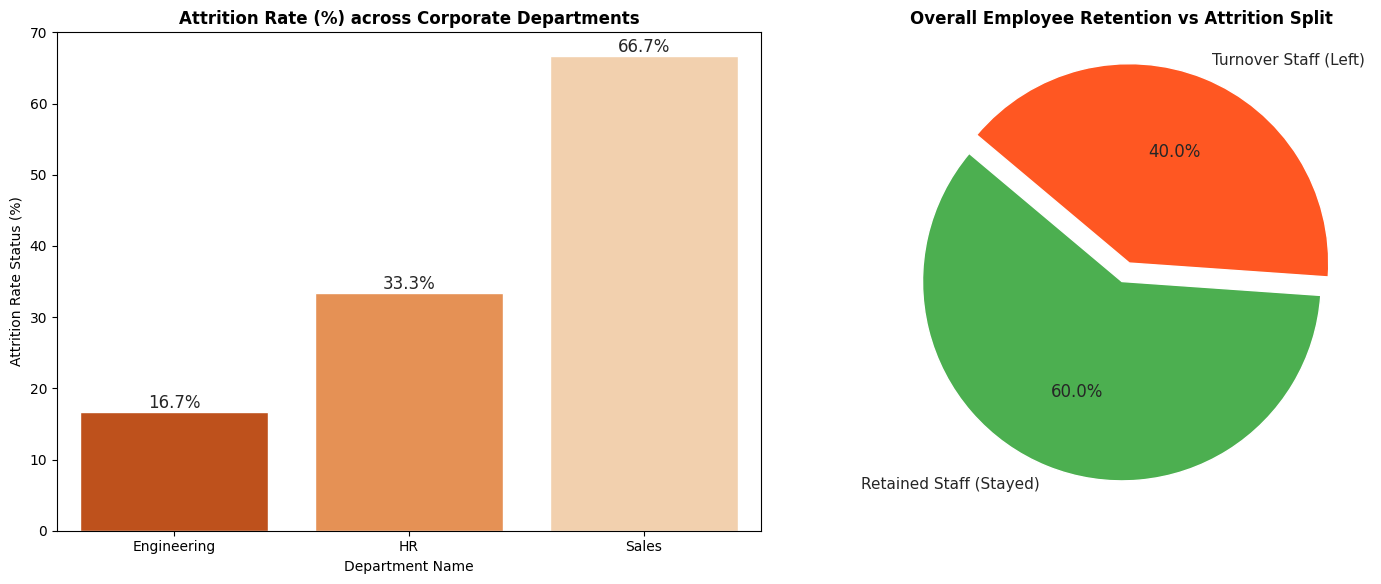


Execution Complete.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------------------------
# STEP 1: DATA CREATION (Simulating the HR Dataset)
# --------------------------------------------------------------------
print("--- Step 1: Loading Dataset ---")
raw_data = {
    'Employee_ID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 102, 111, 112, 113, 114, 115],
    'Department': ['Sales', 'HR', 'Engineering', 'Sales', 'Engineering', 'HR', 'Engineering', 'Sales', 'Engineering', 'Sales', 'HR', 'Sales', 'Engineering', 'HR', 'Engineering', 'Sales'],
    'Salary_Level': ['Low', 'High', 'Medium', 'Medium', 'Low', 'Medium', 'High', 'Low', 'Medium', 'High', 'High', 'Low', 'High', 'Low', 'Medium', 'Medium'],
    'Experience_Years': [1, 7, 5, 2, 3, 6, 9, 1, 4, 8, 7, 2, 10, 1, 4, 5],
    'Left': [1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0]  # 1 = Left, 0 = Stayed
}

df = pd.DataFrame(raw_data)
print(f"Initial Dataset Shape: {df.shape}")
print(df.head(), "\n")

# --------------------------------------------------------------------
# STEP 2: DATA CLEANING & PREPROCESSING
# --------------------------------------------------------------------
print("--- Step 2: Data Cleaning ---")

# 1. Checking for Null Values
print("Missing Values per Column:")
print(df.isnull().sum())

# 2. Checking and Removing Duplicates
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed successfully.")

print(f"Cleaned Dataset Shape: {df.shape}\n")

# --------------------------------------------------------------------
# STEP 3: EXPLORATORY DATA ANALYSIS (Using GroupBy)
# --------------------------------------------------------------------
print("--- Step 3: Analyzing Attrition Trends ---")

# 1. Attrition Rate by Department
# We multiply by 100 to get the percentage value
dept_analysis = df.groupby('Department')['Left'].mean() * 100
print("\n[Insights] Attrition Rate by Department (%):")
print(dept_analysis.round(2))

# 2. Attrition Rate by Salary Level
salary_analysis = df.groupby('Salary_Level')['Left'].mean() * 100
print("\n[Insights] Attrition Rate by Salary Level (%):")
print(salary_analysis.round(2))

# 3. Attrition Rate by Experience Group (Binning data)
# Creating categorical groups out of continuous numbers
df['Experience_Group'] = pd.cut(df['Experience_Years'],
                                bins=[0, 2, 5, 12],
                                labels=['Junior (0-2 yrs)', 'Mid-level (3-5 yrs)', 'Senior (6+ yrs)'])

exp_analysis = df.groupby('Experience_Group')['Left'].mean() * 100
print("\n[Insights] Attrition Rate by Experience Tier (%):")
print(exp_analysis.round(2))

# --------------------------------------------------------------------
# STEP 4: DATA VISUALIZATION
# --------------------------------------------------------------------
print("\n--- Step 4: Generating Visualization Plots ---")

# Set up the plotting grid canvas (1 Row, 2 Columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

# Plot A: Bar Chart for Department Attrition
sns.barplot(ax=axes[0], x=dept_analysis.index, y=dept_analysis.values, palette='Oranges_r')
axes[0].set_title('Attrition Rate (%) across Corporate Departments', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Department Name', fontsize=10)
axes[0].set_ylabel('Attrition Rate Status (%)', fontsize=10)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%') # Adds percentage text on top of bars

# Plot B: Pie Chart for Overall Dataset Attrition Composition
attrition_counts = df['Left'].value_counts()
axes[1].pie(attrition_counts,
            labels=['Retained Staff (Stayed)', 'Turnover Staff (Left)'],
            autopct='%1.1f%%',
            colors=['#4CAF50', '#FF5722'],
            startangle=140,
            explode=(0, 0.1)) # Explodes the 'Left' slice slightly for impact
axes[1].set_title('Overall Employee Retention vs Attrition Split', fontsize=12, fontweight='bold')

# Adjust plot layout spacing and display
plt.tight_layout()
plt.show()

print("\n====================================================================")
print("Execution Complete.")